In [1]:
import os, random
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GENRES = ['blues','classical','country','disco','hiphop',
          'jazz','metal','pop','reggae','rock']
DATA_PATH = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/genres_original"

SAMPLE_RATE   = 22050
N_MELS        = 128
HOP_LENGTH    = 512
NUM_SEGMENTS  = 10
SAMPLES_PER_TRACK   = SAMPLE_RATE * 30
SAMPLES_PER_SEGMENT = SAMPLES_PER_TRACK // NUM_SEGMENTS
EXPECTED_FRAMES     = int(np.ceil(SAMPLES_PER_SEGMENT / HOP_LENGTH))

print("Device:", DEVICE)
print(f"Mỗi segment: {SAMPLES_PER_SEGMENT} samples → {EXPECTED_FRAMES} frames")
print("✅ Setup xong!")

Device: cuda
Mỗi segment: 66150 samples → 130 frames
✅ Setup xong!


In [2]:
print("Bắt đầu extract...")
X, y, groups = [], [], []

for genre in GENRES:
    genre_folder = os.path.join(DATA_PATH, genre)
    files = sorted([f for f in os.listdir(genre_folder) if f.endswith('.wav')])
    for filename in tqdm(files, desc=genre):
        file_path = os.path.join(genre_folder, filename)
        original_file = filename.replace('.wav', '')
        try:
            signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
            for d in range(NUM_SEGMENTS):
                start  = SAMPLES_PER_SEGMENT * d
                finish = start + SAMPLES_PER_SEGMENT
                segment = signal[start:finish]
                if len(segment) < SAMPLES_PER_SEGMENT:
                    continue
                mel = librosa.feature.melspectrogram(
                    y=segment, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
                mel = librosa.power_to_db(mel, ref=np.max)
                if mel.shape[1] == EXPECTED_FRAMES:
                    X.append(mel.T)
                    y.append(GENRES.index(genre))
                    groups.append(original_file)
        except:
            continue

X      = np.array(X, dtype=np.float32)
y      = np.array(y, dtype=np.int64)
groups = np.array(groups)

# Lưu cache
np.save('/kaggle/working/X_mel.npy', X)
np.save('/kaggle/working/y_mel.npy', y)
np.save('/kaggle/working/groups_mel.npy', groups)

print(f"✅ X: {X.shape}, y: {y.shape}, groups: {len(np.unique(groups))} bài")

Bắt đầu extract...


jazz:  54%|█████▍    | 54/100 [00:06<00:04,  9.30it/s]/tmp/ipykernel_22/3372441440.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
rock: 100%|██████████| 100/100 [00:09<00:00, 10.93it/s]


✅ X: (9981, 130, 128), y: (9981,), groups: 999 bài


In [3]:
# GroupShuffleSplit
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
gss_val  = GroupShuffleSplit(n_splits=1, test_size=0.15/0.85, random_state=SEED)

trainval_idx, test_idx = next(gss_test.split(X, y, groups))
X_trainval, y_trainval = X[trainval_idx], y[trainval_idx]
X_test,     y_test     = X[test_idx],     y[test_idx]
groups_trainval        = groups[trainval_idx]

train_idx, val_idx = next(gss_val.split(X_trainval, y_trainval, groups_trainval))
X_train, y_train = X_trainval[train_idx], y_trainval[train_idx]
X_val,   y_val   = X_trainval[val_idx],   y_trainval[val_idx]

print(f"Train: {X_train.shape} — {len(np.unique(groups_trainval[train_idx]))} bài")
print(f"Val:   {X_val.shape}   — {len(np.unique(groups_trainval[val_idx]))} bài")
print(f"Test:  {X_test.shape}  — {len(np.unique(groups[test_idx]))} bài")

# Normalize
mean = X_train.mean()
std  = X_train.std()
X_train = (X_train - mean) / (std + 1e-8)
X_val   = (X_val   - mean) / (std + 1e-8)
X_test  = (X_test  - mean) / (std + 1e-8)
print(f"✅ Normalized")

# DataLoader
class MelDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.FloatTensor(X).unsqueeze(1)  # (N, 1, T, F)
        self.y = torch.LongTensor(y)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if random.random() < 0.5:
                t = random.randint(0, 20)
                t0 = random.randint(0, x.shape[1] - t)
                x[:, t0:t0+t, :] = 0
            if random.random() < 0.5:
                f = random.randint(0, 20)
                f0 = random.randint(0, x.shape[2] - f)
                x[:, :, f0:f0+f] = 0
        return x, self.y[idx]

train_loader = DataLoader(MelDataset(X_train, y_train, augment=True),
                          batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(MelDataset(X_val, y_val),
                          batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(MelDataset(X_test, y_test),
                          batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoader ready — Train: {len(train_loader)} batches")

Train: (6983, 130, 128) — 699 bài
Val:   (1500, 130, 128)   — 150 bài
Test:  (1498, 130, 128)  — 150 bài
✅ Normalized
✅ DataLoader ready — Train: 219 batches


In [4]:
class MusicCNNLSTM(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.lstm = nn.LSTM(128*16, 256, num_layers=2,
                            batch_first=True, dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)
        B, C, T, F = x.shape
        x = x.permute(0, 2, 1, 3).reshape(B, T, C*F)
        _, (hn, _) = self.lstm(x)
        x = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.classifier(x)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
        total += len(y_batch)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / len(loader), correct / total

# Khởi tạo
model = MusicCNNLSTM().to(DEVICE)
dummy = torch.zeros(2, 1, 130, 128).to(DEVICE)
print("Output shape:", model(dummy).shape)
print(f"Total params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)
print("✅ Ready!")

Output shape: torch.Size([2, 10])
Total params: 6,604,650
✅ Ready!


In [5]:
EPOCHS = 100
best_val_acc = 0
best_model_state = None
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
patience_counter = 0
PATIENCE = 20

print("🚀 Bắt đầu train CNN2D+BiLSTM...")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = eval_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        tag = "✅"
    else:
        patience_counter += 1
        tag = ""

    print(f"Epoch {epoch:03d}/{EPOCHS} | "
          f"Train: {train_acc:.4f} Loss: {train_loss:.4f} | "
          f"Val: {val_acc:.4f} Loss: {val_loss:.4f} {tag}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping tại epoch {epoch}")
        break

print(f"\n🏆 Best Val Accuracy: {best_val_acc:.4f}")
model.load_state_dict(best_model_state)
torch.save(best_model_state, '/kaggle/working/cnn_lstm_best.pt')
print("✅ Đã lưu model!")

🚀 Bắt đầu train CNN2D+BiLSTM...
Epoch 001/100 | Train: 0.3380 Loss: 1.9294 | Val: 0.4073 Loss: 1.7400 ✅
Epoch 002/100 | Train: 0.4557 Loss: 1.6655 | Val: 0.4680 Loss: 1.6259 ✅
Epoch 003/100 | Train: 0.5274 Loss: 1.5430 | Val: 0.5067 Loss: 1.5574 ✅
Epoch 004/100 | Train: 0.5595 Loss: 1.4691 | Val: 0.5253 Loss: 1.5866 ✅
Epoch 005/100 | Train: 0.5969 Loss: 1.4011 | Val: 0.5813 Loss: 1.4380 ✅
Epoch 006/100 | Train: 0.6211 Loss: 1.3664 | Val: 0.5993 Loss: 1.4101 ✅
Epoch 007/100 | Train: 0.6506 Loss: 1.3164 | Val: 0.5967 Loss: 1.4510 
Epoch 008/100 | Train: 0.6670 Loss: 1.2735 | Val: 0.5813 Loss: 1.4539 
Epoch 009/100 | Train: 0.6867 Loss: 1.2372 | Val: 0.6380 Loss: 1.3172 ✅
Epoch 010/100 | Train: 0.7066 Loss: 1.1932 | Val: 0.6393 Loss: 1.2928 ✅
Epoch 011/100 | Train: 0.7200 Loss: 1.1572 | Val: 0.6540 Loss: 1.3124 ✅
Epoch 012/100 | Train: 0.7414 Loss: 1.1304 | Val: 0.6667 Loss: 1.2921 ✅
Epoch 013/100 | Train: 0.7510 Loss: 1.0915 | Val: 0.6593 Loss: 1.2953 
Epoch 014/100 | Train: 0.7593 Loss:

CNN2D+BiLSTM FINAL RESULTS (Test Set)
Accuracy:    0.8011
F1 Macro:    0.7925
F1 Weighted: 0.7955

              precision    recall  f1-score   support

       blues       0.94      0.72      0.81       180
   classical       0.79      1.00      0.88       100
     country       0.82      0.93      0.87       150
       disco       0.79      0.83      0.81       150
      hiphop       0.80      0.73      0.76        99
        jazz       0.84      0.90      0.87       220
       metal       0.87      0.99      0.93       140
         pop       0.71      0.79      0.75       140
      reggae       0.74      0.68      0.71       190
        rock       0.64      0.47      0.54       129

    accuracy                           0.80      1498
   macro avg       0.79      0.80      0.79      1498
weighted avg       0.80      0.80      0.80      1498



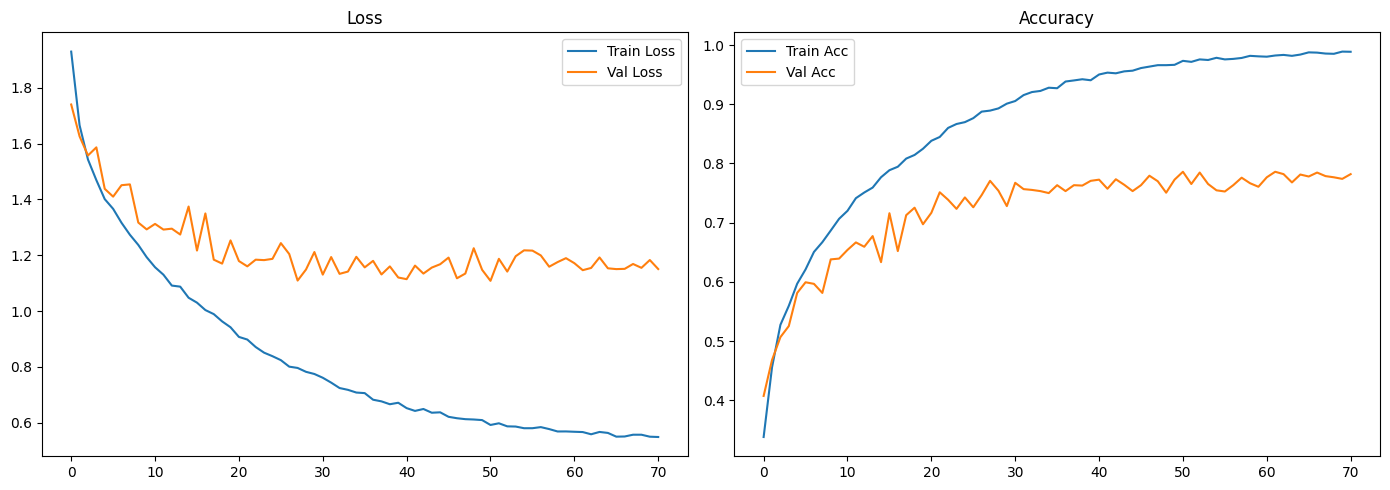

✅ Xong!


In [6]:
# Load best model và evaluate
model.load_state_dict(best_model_state)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc  = accuracy_score(all_labels, all_preds)
f1_m = f1_score(all_labels, all_preds, average='macro')
f1_w = f1_score(all_labels, all_preds, average='weighted')

print(f"{'='*45}")
print(f"CNN2D+BiLSTM FINAL RESULTS (Test Set)")
print(f"{'='*45}")
print(f"Accuracy:    {acc:.4f}")
print(f"F1 Macro:    {f1_m:.4f}")
print(f"F1 Weighted: {f1_w:.4f}")
print(f"\n{classification_report(all_labels, all_preds, target_names=GENRES)}")

# Learning curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/learning_curve.png', dpi=100)
plt.show()
print("✅ Xong!")

In [7]:
import pickle, os

RESULTS_DIR = '/kaggle/working/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Lưu metrics
import pandas as pd
row = {
    'model': 'CNN2D_BiLSTM',
    'accuracy': round(acc, 4),
    'f1_macro': round(f1_m, 4),
    'f1_weighted': round(f1_w, 4),
    'notes': 'CNN2D+BiLSTM on Mel Spectrogram, GroupShuffleSplit'
}
pd.DataFrame([row]).to_csv(f'{RESULTS_DIR}/dl_metrics.csv', index=False)

# Lưu predictions cho D
dl_preds = {
    'CNN_LSTM': {
        'accuracy': acc,
        'y_pred': all_preds,
        'y_test': all_labels
    },
    'genres': GENRES
}
with open(f'{RESULTS_DIR}/dl_predictions.pkl', 'wb') as f:
    pickle.dump(dl_preds, f)

# Lưu model info
print("📊 TỔNG KẾT TASK C:")
print(f"  Model: CNN2D + BiLSTM")
print(f"  Input: Mel Spectrogram (130, 128)")
print(f"  Split: GroupShuffleSplit (train=699, val=150, test=150 bài)")
print(f"  Test Accuracy: {acc:.4f}")
print(f"  F1 Macro:      {f1_m:.4f}")
print(f"  F1 Weighted:   {f1_w:.4f}")

# Checklist
files = [
    '/kaggle/working/cnn_lstm_best.pt',
    f'{RESULTS_DIR}/dl_metrics.csv',
    f'{RESULTS_DIR}/dl_predictions.pkl',
    '/kaggle/working/learning_curve.png',
]
print("\n✅ CHECKLIST:")
for f in files:
    print("✅" if os.path.exists(f) else "❌", f)

📊 TỔNG KẾT TASK C:
  Model: CNN2D + BiLSTM
  Input: Mel Spectrogram (130, 128)
  Split: GroupShuffleSplit (train=699, val=150, test=150 bài)
  Test Accuracy: 0.8011
  F1 Macro:      0.7925
  F1 Weighted:   0.7955

✅ CHECKLIST:
✅ /kaggle/working/cnn_lstm_best.pt
✅ /kaggle/working/results/dl_metrics.csv
✅ /kaggle/working/results/dl_predictions.pkl
✅ /kaggle/working/learning_curve.png
